# x86 CPU Governor - Inherited ML Experts + Optuna-tuned Dual-frequency DDQN

This notebook re-trains **only the RL agent** of
`CPU_Governor_X86_MLP_one_Students_16_bins_DualFreq_DDQN.ipynb`. The ML experts are
**inherited and frozen**:

- the 64x64 configuration-score MLP student (PCHIP-teacher distilled, unchanged);
- the 32x32 direct measured-label frequency MLP expert (unchanged);
- the PCHIP configuration teacher is kept as an *alternative reward source*.

The dual-head 16-bin DDQN is then trained under an **Optuna (TPE)** hyper-parameter search
whose objective is the **maximum measurable EDP gain** over the ten x86 utilisation states.

## Why search "where the reward comes from" too

With `gamma=0` the DDQN is a contextual-bandit warm start: its config head regresses toward
the warm-start reward surface, so the final policy is `argmax` of that surface. The agent can
therefore never be better than the surface used to warm it:

- a **student**-derived config reward caps at the student policy (~12.5% oracle regret);
- a **teacher**-derived config reward caps near the teacher policy (~6.9% oracle regret).

The search therefore also tunes `reward_source in {student, teacher, mix}` - the only knob
that actually moves the headline, along with the usual DDQN hyper-parameters.

## Training protocol

1. **Tier 1 (search):** inherited experts are fitted/persisted once; the DDQN is trained on a
   surface from the 8 interior utilisation states and scored on the two held-out extreme
   states (`x86@10`, `x86@100`) - fast, leakage-safe, and correlated with the rigorous
   protocol (single seed, seconds per trial).
2. **Tier 2 (rigorous validation):** the best trials are re-trained under the original
   leave-one-state-out protocol (per-fold experts, three RL seeds) and reported with the
   same metric tables as the parent notebook.


In [1]:
from __future__ import annotations

import json
import os
import re
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
optuna.logging.set_verbosity(optuna.logging.WARNING)


@dataclass
class CFG:
    remote_url: str = "https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv"
    local_csv: str = "data/x86_mm1_clean.csv"
    seed: int = 42
    rl_seeds: Tuple[int, ...] = (7, 42, 123)
    sampling_rates: Tuple[int, ...] = tuple(range(10_000, 100_001, 10_000))
    thresholds: Tuple[int, ...] = (75, 80, 85, 90, 95)
    ondemand_sr: int = 10_000
    ondemand_thr: int = 95
    rho_eps: float = 1e-3
    fmin_khz: float = 800_000.0
    fmax_khz: float = 2_100_000.0

    config_student_hidden: Tuple[int, ...] = (64, 64)
    config_distill_points: int = 256
    config_student_epochs: int = 1_400
    config_student_lr: float = 2e-3

    freq_expert_hidden: Tuple[int, ...] = (32, 32)
    freq_expert_epochs: int = 900
    freq_expert_lr: float = 5e-3

    gamma: float = 0.0
    rl_grid_points: int = 96
    rl_steps: int = 2_000
    rl_batch: int = 128
    rl_lr: float = 3e-3
    rl_hidden: Tuple[int, ...] = (48, 48)
    rl_target_tau: float = 0.05
    rl_eps_start: float = 1.0
    rl_eps_end: float = 0.05
    n_frequency_bins: int = 16
    lambda_frequency: float = 2.0
    results_dir: str = "results_x86_optuna_ddqn"


CFG_ = CFG()
RESULTS = Path(CFG_.results_dir)
ASSETS_DIR = RESULTS / "inherited_experts"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG_.seed)

N_TRIALS: int = int(os.environ.get("N_TRIALS", "60"))
N_VALIDATE: int = int(os.environ.get("N_VALIDATE", "3"))
SEARCH_SEED: int = 42

print(f"Config loaded. ML experts will be persisted under {ASSETS_DIR.resolve()}")
print(f"Optuna plan: {N_TRIALS} proxy search trials; top-{N_VALIDATE} validated with rigorous LOOCV x 3 seeds.")


/tmp/opencode/rlvenv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config loaded. ML experts will be persisted under /home/ayman.zahir/github/PPDS-project/notebooks/results_x86_optuna_ddqn/inherited_experts
Optuna plan: 25 proxy search trials; top-2 validated with rigorous LOOCV x 3 seeds.


In [2]:
CANONICAL = {
    "util_target_pct": ["cpuutilization", "targetedutilization", "targetutilization"],
    "sampling_rate_us": ["samplingrate"],
    "threshold_pct": ["threshold"],
    "mrt_ms": ["measuredmrt"],
    "power_w": ["measuredcorepower"],
    "freq_khz": ["measuredmeancorefrequency"],
    "measured_util_pct": ["measuredutilization"],
}


def norm_name(name):
    s = re.sub(r"\[.*?\]|\(.*?\)", " ", str(name))
    return re.sub(r"[^0-9a-zA-Z]+", "", s.replace("\u00b5", "u")).lower()


def resolve_columns(df):
    lookup = {norm_name(c): c for c in df.columns}
    out = {}
    for key, candidates in CANONICAL.items():
        for candidate in candidates:
            if candidate in lookup:
                out[key] = lookup[candidate]
                break
    missing = sorted(set(CANONICAL) - set(out))
    if missing:
        raise KeyError(f"Missing columns: {missing}; available={list(df.columns)}")
    return out


try:
    raw = pd.read_csv(CFG_.remote_url)
    DATA_SOURCE = CFG_.remote_url
except Exception:
    raw = pd.read_csv(CFG_.local_csv)
    DATA_SOURCE = CFG_.local_csv

cols = resolve_columns(raw)
runs = pd.DataFrame({key: pd.to_numeric(raw[col], errors="coerce") for key, col in cols.items()})
runs = runs.dropna().copy()
runs["sampling_rate_us"] = runs["sampling_rate_us"].astype(int)
runs["threshold_pct"] = runs["threshold_pct"].astype(int)
runs["util_target_pct"] = runs["util_target_pct"].round(6)
runs["edp"] = runs["mrt_ms"] ** 2 * runs["power_w"]

ACTION_GRID = pd.DataFrame(
    [(sr, thr) for sr in CFG_.sampling_rates for thr in CFG_.thresholds],
    columns=["sampling_rate_us", "threshold_pct"],
)
ACTION_GRID.insert(0, "config_id", np.arange(len(ACTION_GRID)))
ACTION_GRID["sr_norm"] = (ACTION_GRID.sampling_rate_us - min(CFG_.sampling_rates)) / (max(CFG_.sampling_rates) - min(CFG_.sampling_rates))
ACTION_GRID["thr_norm"] = (ACTION_GRID.threshold_pct - min(CFG_.thresholds)) / (max(CFG_.thresholds) - min(CFG_.thresholds))
N_ACTIONS = len(ACTION_GRID)
SR_ARR = ACTION_GRID.sampling_rate_us.to_numpy()
THR_ARR = ACTION_GRID.threshold_pct.to_numpy()
SRN_ARR = ACTION_GRID.sr_norm.to_numpy()
THRN_ARR = ACTION_GRID.thr_norm.to_numpy()
ONDEMAND_ID = int(ACTION_GRID.query("sampling_rate_us == @CFG_.ondemand_sr and threshold_pct == @CFG_.ondemand_thr").config_id.iloc[0])
assert N_ACTIONS == 50

keys = ["util_target_pct", "sampling_rate_us", "threshold_pct"]
TABLE = (runs.groupby(keys)
         .agg(edp=("edp", "median"), freq_khz=("freq_khz", "median"), measured_util_pct=("measured_util_pct", "median"), n_reps=("edp", "size"))
         .reset_index().merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="left"))
TABLE["log_edp"] = np.log10(TABLE.edp)
TABLE["state_id"] = "x86@" + TABLE.util_target_pct.map(lambda v: f"{v:g}")

state_rows = []
for util, g in TABLE.groupby("util_target_pct"):
    if set(g.config_id.astype(int)) != set(range(N_ACTIONS)):
        continue
    ond = g[g.config_id == ONDEMAND_ID].iloc[0]
    oracle = g.loc[g.edp.idxmin()]
    rho = float(np.clip(ond.measured_util_pct / 100, CFG_.rho_eps, 1 - CFG_.rho_eps))
    state_rows.append(dict(state_id=f"x86@{util:g}", util_target_pct=float(util), rho=rho,
                           log_1m_rho=float(np.log10(max(1 - rho, CFG_.rho_eps))),
                           oracle_config_id=int(oracle.config_id), edp_oracle=float(oracle.edp),
                           edp_ondemand=float(ond.edp)))
STATES = pd.DataFrame(state_rows).sort_values("util_target_pct").reset_index(drop=True)
STATE_ROW = STATES.set_index("state_id")
STATE_IDS = STATES.state_id.tolist()
assert len(STATE_IDS) == 10

TABLE = TABLE[TABLE.state_id.isin(STATE_IDS)].merge(STATES[["util_target_pct", "rho", "log_1m_rho"]], on="util_target_pct", how="left")
EDP_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="edp").reindex(index=STATE_IDS, columns=range(N_ACTIONS))
FREQ_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="freq_khz").reindex(index=STATE_IDS, columns=range(N_ACTIONS))

print(f"Source: {DATA_SOURCE}")
print(f"Runs={len(runs):,}; complete states={len(STATES)}; actions/state={N_ACTIONS}; aggregated rows={len(TABLE)}")


Source: https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv
Runs=4,979; complete states=10; actions/state=50; aggregated rows=500


In [3]:
class MLP:
    def __init__(self, sizes: Sequence[int], out_act="linear", seed=0, lr=3e-3):
        rng = np.random.default_rng(seed)
        self.sizes, self.out_act, self.lr = list(sizes), out_act, lr
        self.W = [rng.normal(0, np.sqrt(1 / a), (a, b)) for a, b in zip(self.sizes[:-1], self.sizes[1:])]
        self.b = [np.zeros(b) for b in self.sizes[1:]]
        self._reset_adam()

    def _reset_adam(self):
        self.mW = [np.zeros_like(w) for w in self.W]; self.vW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]; self.vb = [np.zeros_like(b) for b in self.b]; self.t = 0

    def forward(self, X, cache=False):
        A = np.asarray(X, dtype=float); acts = [A]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b
            if i < len(self.W) - 1:
                A = np.tanh(Z)
            elif self.out_act == "sigmoid":
                A = 1 / (1 + np.exp(-np.clip(Z, -30, 30)))
            elif self.out_act == "tanh":
                A = np.tanh(Z)
            else:
                A = Z
            acts.append(A)
        if cache:
            self._acts = acts
        return A

    __call__ = forward

    def backward(self, dY):
        acts = self._acts; dW = [None] * len(self.W); db = [None] * len(self.b); Y = acts[-1]
        if self.out_act == "sigmoid":
            dZ = dY * Y * (1 - Y)
        elif self.out_act == "tanh":
            dZ = dY * (1 - Y ** 2)
        else:
            dZ = dY
        for i in range(len(self.W) - 1, -1, -1):
            dW[i] = acts[i].T @ dZ; db[i] = dZ.sum(0); dA = dZ @ self.W[i].T
            dZ = dA * (1 - acts[i] ** 2) if i > 0 else dA
        return dW, db, dZ

    def adam_step(self, dW, db, lr=None, b1=.9, b2=.999, eps=1e-8):
        self.t += 1; lr = self.lr if lr is None else lr
        for i in range(len(self.W)):
            self.mW[i] = b1 * self.mW[i] + (1 - b1) * dW[i]; self.vW[i] = b2 * self.vW[i] + (1 - b2) * dW[i] ** 2
            self.mb[i] = b1 * self.mb[i] + (1 - b1) * db[i]; self.vb[i] = b2 * self.vb[i] + (1 - b2) * db[i] ** 2
            self.W[i] -= lr * (self.mW[i] / (1 - b1 ** self.t)) / (np.sqrt(self.vW[i] / (1 - b2 ** self.t)) + eps)
            self.b[i] -= lr * (self.mb[i] / (1 - b1 ** self.t)) / (np.sqrt(self.vb[i] / (1 - b2 ** self.t)) + eps)

    def fit_regression(self, X, Y, epochs, batch=256, seed=0):
        X = np.asarray(X, float); Y = np.asarray(Y, float).reshape(len(X), -1); rng = np.random.default_rng(seed)
        for _ in range(epochs):
            for start in range(0, len(X), batch):
                ix = rng.permutation(len(X))[start:start + batch]
                pred = self.forward(X[ix], cache=True)
                dW, db, _ = self.backward(2 * (pred - Y[ix]) / (len(ix) * Y.shape[1]))
                self.adam_step(dW, db)
        return self

    def copy(self):
        o = MLP(self.sizes, self.out_act, 0, self.lr); o.W = [w.copy() for w in self.W]; o.b = [b.copy() for b in self.b]; return o

    def soft_update_from(self, src, tau):
        for i in range(len(self.W)):
            self.W[i] = (1 - tau) * self.W[i] + tau * src.W[i]; self.b[i] = (1 - tau) * self.b[i] + tau * src.b[i]

    @property
    def n_params(self):
        return int(sum(w.size for w in self.W) + sum(b.size for b in self.b))

print("MLP implementation ready.")


MLP implementation ready.


In [4]:
class PCHIPConfigurationTeacher:
    def fit(self, table):
        self.rho_min = float(table.rho.min()); self.rho_max = float(table.rho.max()); self.curves = {}
        baseline = table[table.config_id == ONDEMAND_ID].set_index("util_target_pct").log_edp
        for cid, g in table.groupby("config_id"):
            x = g.log_1m_rho.to_numpy(); y = g.log_edp.to_numpy() - g.util_target_pct.map(baseline).to_numpy(); order = np.argsort(x)
            self.curves[int(cid)] = PchipInterpolator(x[order], y[order], extrapolate=True)
        return self

    def score(self, rho):
        x = np.log10(np.clip(1 - np.atleast_1d(rho), CFG_.rho_eps, None))
        return np.column_stack([self.curves[c](x) for c in range(N_ACTIONS)])

    def predict_config(self, rho):
        return np.argmin(self.score(rho), axis=1)


def state_features(rho):
    r = np.atleast_1d(np.asarray(rho, float))
    return np.column_stack([r, np.log10(np.clip(1 - r, CFG_.rho_eps, None))])


class ConfigurationScoreMLPStudent:
    # Returns a reward-like score for every configuration; higher is better.
    def __init__(self, seed=42):
        self.net = MLP([2, *CFG_.config_student_hidden, N_ACTIONS], "linear", seed, CFG_.config_student_lr)

    def distill(self, teacher):
        rho = np.linspace(teacher.rho_min, teacher.rho_max, CFG_.config_distill_points); X = state_features(rho)
        self.xmu = X.mean(0, keepdims=True); self.xsd = X.std(0, keepdims=True) + 1e-9
        q = -teacher.score(rho); q = (q - q.mean(1, keepdims=True)) / (q.std(1, keepdims=True) + 1e-9)
        self.net.fit_regression((X - self.xmu) / self.xsd, q, CFG_.config_student_epochs, batch=128, seed=CFG_.seed)
        self.rho_min, self.rho_max = teacher.rho_min, teacher.rho_max
        return self

    def score(self, rho):
        X = (state_features(rho) - self.xmu) / self.xsd
        return self.net.forward(X)

    def predict_config(self, rho):
        return np.argmax(self.score(rho), axis=1)


def fit_config_stack(train_ids):
    train = TABLE[TABLE.state_id.isin(train_ids)]
    teacher = PCHIPConfigurationTeacher().fit(train)
    student = ConfigurationScoreMLPStudent(CFG_.seed).distill(teacher)
    return teacher, student


FREQ_FEATURES = ["rho", "log_1m_rho", "sr_norm", "thr_norm"]


def freq_features(rho, srn, thrn):
    rho = np.atleast_1d(np.asarray(rho, float)); srn = np.atleast_1d(np.asarray(srn, float)); thrn = np.atleast_1d(np.asarray(thrn, float))
    rho, srn, thrn = np.broadcast_arrays(rho, srn, thrn)
    return np.column_stack([rho.ravel(), np.log10(np.clip(1 - rho.ravel(), CFG_.rho_eps, None)), srn.ravel(), thrn.ravel()])


class FrequencyMLPExpert:
    """Direct regressor from measured state/action features to normalized frequency."""

    def __init__(self, seed=42):
        self.net = MLP([4, *CFG_.freq_expert_hidden, 1], "sigmoid", seed, CFG_.freq_expert_lr)

    def fit(self, table):
        X = table[FREQ_FEATURES].to_numpy(float)
        y = ((table.freq_khz - CFG_.fmin_khz) / (CFG_.fmax_khz - CFG_.fmin_khz)).clip(0, 1).to_numpy().reshape(-1, 1)
        self.net.fit_regression(X, y, CFG_.freq_expert_epochs, batch=128, seed=CFG_.seed)
        self.rho_min = float(table.rho.min()); self.rho_max = float(table.rho.max())
        return self

    def predict_norm(self, rho, srn, thrn):
        return self.net.forward(freq_features(rho, srn, thrn)).ravel().clip(0, 1)

    def predict_grid_norm(self, rho):
        return self.predict_norm(np.full(N_ACTIONS, rho), SRN_ARR, THRN_ARR)

    def predict_grid_khz(self, rho):
        return CFG_.fmin_khz + self.predict_grid_norm(rho) * (CFG_.fmax_khz - CFG_.fmin_khz)


def fit_frequency_expert(train_ids):
    train = TABLE[TABLE.state_id.isin(train_ids)].copy()
    return FrequencyMLPExpert(CFG_.seed).fit(train)

print("Configuration teacher/student and direct 32x32 frequency expert defined.")


Configuration teacher/student and direct 32x32 frequency expert defined.


## 5. Inherit the ML experts (fit once, freeze, persist)

The configuration student and the direct frequency expert are fitted once on all ten states
(deployment assets) and once per leave-one-state-out fold. Both asset sets are persisted with
`joblib` so they are **inherited and frozen**; only the DDQN agent is retrained below.

In [5]:
EXPERTS_CACHE = ASSETS_DIR / "deployment_experts.joblib"
LOOCV_CACHE = ASSETS_DIR / "loocv_experts.joblib"


def fit_inherited_assets(force=False):
    if EXPERTS_CACHE.exists() and not force:
        load = joblib.load(EXPERTS_CACHE)
        DEPLOY_T, DEPLOY_CS, DEPLOY_FE = load["teacher"], load["student"], load["freq_expert"]
        print("Deployment experts inherited from cache (trained on all 10 states).")
    else:
        DEPLOY_T, DEPLOY_CS = fit_config_stack(STATE_IDS)
        DEPLOY_FE = fit_frequency_expert(STATE_IDS)
        joblib.dump({"teacher": DEPLOY_T, "student": DEPLOY_CS, "freq_expert": DEPLOY_FE}, EXPERTS_CACHE)
        print("Deployment experts fitted on all 10 states and persisted.")

    if LOOCV_CACHE.exists() and not force:
        load = joblib.load(LOOCV_CACHE)
        CONFIG_ASSETS, FREQ_ASSETS = load["config"], load["freq"]
        print("Per-fold LOOCV experts inherited from cache (each trained on 9 states).")
    else:
        CONFIG_ASSETS, FREQ_ASSETS = {}, {}
        for sid in STATE_IDS:
            train_ids = [s for s in STATE_IDS if s != sid]
            ct, cs = fit_config_stack(train_ids)
            CONFIG_ASSETS[sid] = {"teacher": ct, "student": cs}
            FREQ_ASSETS[sid] = {"expert": fit_frequency_expert(train_ids)}
        joblib.dump({"config": CONFIG_ASSETS, "freq": FREQ_ASSETS}, LOOCV_CACHE)
        print("Per-fold LOOCV experts fitted and persisted.")
    return DEPLOY_T, DEPLOY_CS, DEPLOY_FE, CONFIG_ASSETS, FREQ_ASSETS


DEPLOY_T, DEPLOY_CS, DEPLOY_FE, CONFIG_ASSETS, FREQ_ASSETS = fit_inherited_assets()

PROXY_HOLDOUT = STATE_IDS[:1] + STATE_IDS[-1:]   # x86@10 and x86@100: the two hardest (extreme) states
PROXY_TRAIN = [s for s in STATE_IDS if s not in PROXY_HOLDOUT]

PROXY_CACHE = ASSETS_DIR / "proxy_experts.joblib"
if PROXY_CACHE.exists():
    load = joblib.load(PROXY_CACHE)
    PROXY_CT, PROXY_CS, PROXY_FE = load["teacher"], load["student"], load["freq_expert"]
    print("Held-out proxy experts inherited from cache (trained on the 8 interior states).")
else:
    PROXY_CT, PROXY_CS = fit_config_stack(PROXY_TRAIN)
    PROXY_FE = fit_frequency_expert(PROXY_TRAIN)
    joblib.dump({"teacher": PROXY_CT, "student": PROXY_CS, "freq_expert": PROXY_FE}, PROXY_CACHE)
    print("Held-out proxy experts fitted on the 8 interior states and persisted.")

print(f"Held-out proxy states for the Tier-1 search: {PROXY_HOLDOUT}")
print(f"Configuration student params={DEPLOY_CS.net.n_params:,}; frequency expert params={DEPLOY_FE.net.n_params:,}")
print(f"Inherited assets cached under {ASSETS_DIR.resolve()}")


Deployment experts inherited from cache (trained on all 10 states).


Per-fold LOOCV experts inherited from cache (each trained on 9 states).
Held-out proxy experts inherited from cache (trained on the 8 interior states).
Held-out proxy states for the Tier-1 search: ['x86@10', 'x86@100']
Configuration student params=7,602; frequency expert params=1,249
Inherited assets cached under /home/ayman.zahir/github/PPDS-project/notebooks/results_x86_optuna_ddqn/inherited_experts


## 6. Warm-start surface with a searchable reward source

The warm-start surface consists of the 16-bin frequency targets `Fnorm` (always from the
inherited direct frequency expert) and a config reward `Q`. `reward_source` selects whether
`Q` comes from the inherited student, the PCHIP teacher (negated, higher=better), or a
weighted blend - this is the reward knob that sets the agent's ceiling.

In [6]:
@dataclass
class WarmStartSurface:
    state_id: str; mu: np.ndarray; sd: np.ndarray; S: np.ndarray; rho_grid: np.ndarray; Q: np.ndarray; Fnorm: np.ndarray

    def encode(self, rho):
        X = state_features(rho)
        return (X - self.mu) / self.sd


def warmstart_surface(config_teacher, config_student, freq_expert, state_id="fold",
                      reward_source="student", mix_student_weight=0.5, grid_points=None):
    lo = max(config_student.rho_min, freq_expert.rho_min, CFG_.rho_eps)
    hi = min(config_student.rho_max, freq_expert.rho_max, 1 - CFG_.rho_eps)
    rho = np.linspace(lo, hi, int(grid_points or CFG_.rl_grid_points))
    raw = state_features(rho)
    mu = raw.mean(0, keepdims=True); sd = raw.std(0, keepdims=True) + 1e-9
    S = (raw - mu) / sd

    raw_student = config_student.score(rho)
    raw_teacher = -config_teacher.score(rho)  # teacher log-EDP offset: lower is better -> negate
    if reward_source == "teacher":
        raw = raw_teacher
    elif reward_source == "mix":
        raw = mix_student_weight * raw_student + (1.0 - mix_student_weight) * raw_teacher
    else:
        raw = raw_student
    Q = (raw - raw.mean()) / (raw.std() + 1e-9)

    F = np.vstack([freq_expert.predict_grid_norm(r) for r in rho])
    return WarmStartSurface(state_id, mu, sd, S, rho, Q, F)


def build_surface(sid, reward_source="student", mix_student_weight=0.5, grid_points=None):
    return warmstart_surface(CONFIG_ASSETS[sid]["teacher"], CONFIG_ASSETS[sid]["student"],
                             FREQ_ASSETS[sid]["expert"], state_id=sid,
                             reward_source=reward_source, mix_student_weight=mix_student_weight,
                             grid_points=grid_points)


def build_deployment_surface(reward_source="student", mix_student_weight=0.5, grid_points=None):
    return warmstart_surface(DEPLOY_T, DEPLOY_CS, DEPLOY_FE, state_id="deployment",
                             reward_source=reward_source, mix_student_weight=mix_student_weight,
                             grid_points=grid_points)


def build_proxy_surface(reward_source="student", mix_student_weight=0.5, grid_points=None):
    return warmstart_surface(PROXY_CT, PROXY_CS, PROXY_FE, state_id="proxy",
                             reward_source=reward_source, mix_student_weight=mix_student_weight,
                             grid_points=grid_points)

probe = build_deployment_surface()
assert probe.Q.shape == (CFG_.rl_grid_points, N_ACTIONS) and probe.Fnorm.shape == probe.Q.shape
print(f"Warm-start surface: states={probe.S.shape}, config reward Q={probe.Q.shape}, frequency targets={probe.Fnorm.shape}")
print("The frequency targets always come from the inherited direct frequency expert.")


Warm-start surface: states=(96, 2), config reward Q=(96, 50), frequency targets=(96, 50)
The frequency targets always come from the inherited direct frequency expert.


## 7. Dual-head 16-bin DDQN (same architecture, tunable hyper-parameters)

The factorised Q-network is unchanged but now accepts `hidden` and `lr` from the search. With
`gamma=0`, DDQN target machinery is retained for architectural continuity; no next-state
reward is invented.

In [7]:
class FactorisedQNet:
    def __init__(self, in_dim, n_actions, n_bins, seed, hidden=(48, 48), lr=3e-3):
        h = hidden[0]
        self.trunk = MLP([in_dim, h], "tanh", seed, lr)
        self.chead = MLP([h, *hidden[1:], n_actions], "linear", seed + 1, lr)
        self.fhead = MLP([h + 2, *hidden[1:], n_bins], "linear", seed + 2, lr)
        self.n_bins = n_bins

    def q_config(self, S, cache=False):
        return self.chead.forward(self.trunk.forward(S, cache=cache), cache=cache)

    def q_freq(self, S, cid, cache=False):
        H = self.trunk.forward(S, cache=cache)
        X = np.column_stack([H, SRN_ARR[cid], THRN_ARR[cid]])
        return self.fhead.forward(X, cache=cache)

    def step_config(self, S, a, y):
        Q = self.q_config(S, True)
        d = np.zeros_like(Q)
        d[np.arange(len(S)), a] = 2 * (Q[np.arange(len(S)), a] - y) / len(S)
        dw, db, dh = self.chead.backward(d)
        dwt, dbt, _ = self.trunk.backward(dh)
        self.chead.adam_step(dw, db); self.trunk.adam_step(dwt, dbt)

    def step_freq(self, S, c, b, y):
        Q = self.q_freq(S, c, True)
        d = np.zeros_like(Q)
        d[np.arange(len(S)), b] = 2 * (Q[np.arange(len(S)), b] - y) / len(S)
        dw, db, dx = self.fhead.backward(d)
        dwt, dbt, _ = self.trunk.backward(dx[:, :-2])
        self.fhead.adam_step(dw, db); self.trunk.adam_step(dwt, dbt)

    def copy(self):
        o = FactorisedQNet.__new__(FactorisedQNet)
        o.trunk = self.trunk.copy(); o.chead = self.chead.copy(); o.fhead = self.fhead.copy(); o.n_bins = self.n_bins
        return o

    def soft_update_from(self, src, tau):
        self.trunk.soft_update_from(src.trunk, tau)
        self.chead.soft_update_from(src.chead, tau)
        self.fhead.soft_update_from(src.fhead, tau)

    @property
    def n_params(self):
        return self.trunk.n_params + self.chead.n_params + self.fhead.n_params


def bin_centers(n_bins):
    e = np.linspace(CFG_.fmin_khz, CFG_.fmax_khz, n_bins + 1)
    return 0.5 * (e[:-1] + e[1:])


DEFAULT_HP = {
    "reward_source": "student",
    "mix_student_weight": 1.0,
    "lambda_frequency": CFG_.lambda_frequency,
    "grid_points": CFG_.rl_grid_points,
    "steps": CFG_.rl_steps,
    "batch": CFG_.rl_batch,
    "lr": CFG_.rl_lr,
    "hidden": int(CFG_.rl_hidden[0]),
    "tau": CFG_.rl_target_tau,
    "eps_start": CFG_.rl_eps_start,
    "eps_end": CFG_.rl_eps_end,
    "n_bins": CFG_.n_frequency_bins,
}


def build_rewards(surface, hp):
    centers = bin_centers(hp["n_bins"])
    cn = (centers - CFG_.fmin_khz) / (CFG_.fmax_khz - CFG_.fmin_khz)
    Rf = hp["lambda_frequency"] * (-(cn[None, None, :] - surface.Fnorm[:, :, None]) ** 2)
    Rc = surface.Q + Rf.max(2)
    return Rc, Rf


def train_ddqn_warmstart(surface, hp, seed):
    rng = np.random.default_rng(seed)
    hidden = (hp["hidden"], hp["hidden"]) if isinstance(hp["hidden"], int) else tuple(hp["hidden"])
    steps = int(hp["steps"]); batch = int(hp["batch"])
    Rc, Rf = build_rewards(surface, hp)
    centers = bin_centers(hp["n_bins"])
    online = FactorisedQNet(surface.S.shape[1], N_ACTIONS, hp["n_bins"], seed, hidden=hidden, lr=hp["lr"])
    target = online.copy()
    G = len(surface.S)
    for step in range(steps):
        eps = hp["eps_end"] + (hp["eps_start"] - hp["eps_end"]) * (1 - step / max(1, steps))
        gi = rng.integers(0, G, batch)
        S = surface.S[gi]
        gc = np.argmax(online.q_config(S), 1)
        c = np.where(rng.random(batch) < eps, rng.integers(0, N_ACTIONS, batch), gc)
        yc = Rc[gi, c] + CFG_.gamma * target.q_config(S)[np.arange(batch), np.argmax(online.q_config(S), 1)]
        online.step_config(S, c, yc)
        gb = np.argmax(online.q_freq(S, c), 1)
        b = np.where(rng.random(batch) < eps, rng.integers(0, hp["n_bins"], batch), gb)
        yf = Rf[gi, c, b] + CFG_.gamma * target.q_freq(S, c)[np.arange(batch), np.argmax(online.q_freq(S, c), 1)]
        online.step_freq(S, c, b, yf)
        target.soft_update_from(online, hp["tau"])
    return online, centers


def agent_action(net, centers, surface, rho):
    S = surface.encode(rho)
    cid = int(np.argmax(net.q_config(S), 1)[0])
    bid = int(np.argmax(net.q_freq(S, np.array([cid])), 1)[0])
    return dict(config_id=cid, sampling_rate_us=int(SR_ARR[cid]), threshold_pct=int(THR_ARR[cid]),
                frequency_bin_id=bid, frequency_khz=float(centers[bid]))

print("Dual-head DDQN architecture defined; training and inference are driven by the Optuna `hp` dict.")
print(f"DEFAULT_HP reproduces the parent notebook exactly: {DEFAULT_HP}")


Dual-head DDQN architecture defined; training and inference are driven by the Optuna `hp` dict.
DEFAULT_HP reproduces the parent notebook exactly: {'reward_source': 'student', 'mix_student_weight': 1.0, 'lambda_frequency': 2.0, 'grid_points': 96, 'steps': 2000, 'batch': 128, 'lr': 0.003, 'hidden': 48, 'tau': 0.05, 'eps_start': 1.0, 'eps_end': 0.05, 'n_bins': 16}


## 8. Evaluation helpers
1. **Tier 1 proxy** - train once on a surface built from the 8 interior states, score on the
   two held-out extreme states (`x86@10`, `x86@100`). Used for the Optuna objective: fast and
   leakage-safe, so it correlates with the rigorous numbers.
2. **Tier 2 rigorous** - original leave-one-state-out protocol: per-fold inherited experts,
   three RL seeds. Used to validate the top trials.
3. Baseline LOOCV tables (teacher / student / ondemand) are rebuilt from the inherited
   per-fold assets so the final comparison matches the parent notebook.

In [8]:
def policy_row(sid, policy, cid):
    row = STATE_ROW.loc[sid]
    edp = float(EDP_MATRIX.loc[sid, cid])
    return dict(state_id=sid, policy=policy, config_id=int(cid), regret=edp / row.edp_oracle - 1,
                delta_vs_ondemand=edp / row.edp_ondemand - 1, exact_oracle=int(cid) == int(row.oracle_config_id))


def config_metrics(g):
    return dict(mean_regret=float(g.regret.mean()), median_regret=float(g.regret.median()), worst_regret=float(g.regret.max()),
                exact_oracle_rate=float(g.exact_oracle.mean()), within_5pct_oracle=float((g.regret <= 0.05).mean()),
                mean_delta_vs_ondemand=float(g.delta_vs_ondemand.mean()), better_than_ondemand=float((g.delta_vs_ondemand < 0).mean()))


CONFIG_LOOCV_rows = []
FREQ_LOOCV_rows = []
for sid in STATE_IDS:
    rho = float(STATE_ROW.loc[sid, "rho"])
    CONFIG_LOOCV_rows += [policy_row(sid, "Oracle", int(STATE_ROW.loc[sid, "oracle_config_id"])),
                          policy_row(sid, "Linux Ondemand", ONDEMAND_ID),
                          policy_row(sid, "PCHIP Teacher", int(CONFIG_ASSETS[sid]["teacher"].predict_config(rho)[0])),
                          policy_row(sid, "MLP Configuration Student", int(CONFIG_ASSETS[sid]["student"].predict_config(rho)[0]))]
    measured_khz = FREQ_MATRIX.loc[sid].to_numpy(float)
    expert_khz = FREQ_ASSETS[sid]["expert"].predict_grid_khz(rho)
    for cid in range(N_ACTIONS):
        FREQ_LOOCV_rows.append(dict(state_id=sid, config_id=cid, measured_khz=measured_khz[cid], expert_khz=expert_khz[cid]))

CONFIG_LOOCV = pd.DataFrame(CONFIG_LOOCV_rows)
FREQ_LOOCV = pd.DataFrame(FREQ_LOOCV_rows)
CONFIG_SUMMARY = pd.DataFrame([{"policy": p, **config_metrics(g)} for p, g in CONFIG_LOOCV.groupby("policy")]).sort_values("mean_regret")
FREQ_SUMMARY = pd.DataFrame([dict(model="Direct Frequency-Expert",
                                  MAE_MHz=float(np.abs(FREQ_LOOCV.expert_khz - FREQ_LOOCV.measured_khz).mean()) / 1e3,
                                  RMSE_MHz=float(np.sqrt(np.mean((FREQ_LOOCV.expert_khz - FREQ_LOOCV.measured_khz) ** 2))) / 1e3,
                                  R2=float(r2_score(FREQ_LOOCV.measured_khz, FREQ_LOOCV.expert_khz)))])

print("INHERITED-EXPERT LOOCV BASELINES (same protocol as the parent notebook)")
print(CONFIG_SUMMARY.to_string(index=False))
print()
print(FREQ_SUMMARY.to_string(index=False))


INHERITED-EXPERT LOOCV BASELINES (same protocol as the parent notebook)
                   policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand
                   Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                1.0000
            PCHIP Teacher       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                1.0000
MLP Configuration Student       0.1248         0.0236        0.8733             0.4000              0.7000                 -0.1892                1.0000
           Linux Ondemand       0.5664         0.2337        3.6524             0.0000              0.0000                  0.0000                0.0000

                  model  MAE_MHz  RMSE_MHz     R2
Direct Frequency-Expert  16.8732   37.5092 0.9211


In [9]:
def eval_rows_for(surface, net, centers, sid):
    rho = float(STATE_ROW.loc[sid, "rho"])
    act = agent_action(net, centers, surface, rho)
    cid = act["config_id"]
    row = STATE_ROW.loc[sid]
    edp = float(EDP_MATRIX.loc[sid, cid])
    return dict(state_id=sid, **act, regret=edp / row.edp_oracle - 1,
                delta_vs_ondemand=edp / row.edp_ondemand - 1, exact_oracle=cid == int(row.oracle_config_id))


def evaluate_proxy(hp, seed=SEARCH_SEED):
    # Tier-1: train once on a surface built from the 8 interior states and score on the
    # two held-out extreme states (x86@10, x86@100). Fast and leakage-safe for the search.
    surface = build_proxy_surface(hp["reward_source"], hp["mix_student_weight"], hp["grid_points"])
    net, centers = train_ddqn_warmstart(surface, hp, seed)
    rows = pd.DataFrame([eval_rows_for(surface, net, centers, sid) for sid in PROXY_HOLDOUT])
    return surface, net, centers, rows


def evaluate_loocv(hp, seeds):
    rl_rows = []
    for sid in STATE_IDS:
        surface = build_surface(sid, hp["reward_source"], hp["mix_student_weight"], hp["grid_points"])
        rho = float(STATE_ROW.loc[sid, "rho"])
        for seed in seeds:
            net, centers = train_ddqn_warmstart(surface, hp, seed)
            act = agent_action(net, centers, surface, rho)
            cid = act["config_id"]
            row = STATE_ROW.loc[sid]
            edp = float(EDP_MATRIX.loc[sid, cid])
            measured = float(FREQ_MATRIX.loc[sid, cid])
            target = float(FREQ_ASSETS[sid]["expert"].predict_grid_khz(rho)[cid])
            rl_rows.append(dict(state_id=sid, seed=seed, **act, regret=edp / row.edp_oracle - 1,
                                delta_vs_ondemand=edp / row.edp_ondemand - 1,
                                exact_oracle=cid == int(row.oracle_config_id),
                                freq_expert_khz=target, freq_measured_khz=measured,
                                freq_err_vs_expert_khz=abs(act["frequency_khz"] - target),
                                freq_err_vs_measured_khz=abs(act["frequency_khz"] - measured),
                                freq_legal=CFG_.fmin_khz <= act["frequency_khz"] <= CFG_.fmax_khz))
    df = pd.DataFrame(rl_rows)
    if len(df) == 0:
        return df, None, None
    per = [config_metrics(g) for _, g in df.groupby("seed")]
    out = {k: float(np.mean([x[k] for x in per])) for k in per[0]}
    out["seed_std_mean_regret"] = float(np.std([x["mean_regret"] for x in per]))
    freq = dict(MAE_vs_expert_MHz=float(df.freq_err_vs_expert_khz.mean()) / 1e3,
                MAE_vs_measured_MHz=float(df.freq_err_vs_measured_khz.mean()) / 1e3,
                legal_violation_pct=100.0 * float(1 - df.freq_legal.mean()))
    return df, out, freq

print("Evaluation helpers ready (Tier-1 deployment proxy + Tier-2 rigorous LOOCV).")


Evaluation helpers ready (Tier-1 deployment proxy + Tier-2 rigorous LOOCV).


## 9. Optuna TPE search

Objective (minimised): **mean oracle regret** on the two held-out extreme x86 states under a
leakage-safe proxy (agents trained on the interior-state surface; single seed). Every trial
also records `gain_vs_ondemand` (negative of mean EDP delta vs ondemand) and the exact-oracle
hit rate.

The parent notebook's original hyper-parameters are enqueued as the first trial, so the study
explicitly anchors on (and should then beat) the 12.48% baseline.

In [10]:
def suggest_hp(trial):
    hp = dict(DEFAULT_HP)
    hp["reward_source"] = trial.suggest_categorical("reward_source", ["student", "teacher", "mix"])
    if hp["reward_source"] == "mix":
        hp["mix_student_weight"] = trial.suggest_float("mix_student_weight", 0.0, 1.0)
    else:
        hp["mix_student_weight"] = 1.0 if hp["reward_source"] == "student" else 0.0
    hp["lambda_frequency"] = trial.suggest_float("lambda_frequency", 0.1, 10.0, log=True)
    hp["grid_points"] = trial.suggest_int("grid_points", 48, 256)
    hp["steps"] = trial.suggest_int("steps", 800, 3500)
    hp["batch"] = trial.suggest_int("batch", 64, 256)
    hp["lr"] = trial.suggest_float("lr", 3e-4, 6e-3, log=True)
    hp["hidden"] = trial.suggest_categorical("hidden", [32, 48, 64])
    hp["tau"] = trial.suggest_float("tau", 0.01, 0.2, log=True)
    hp["eps_start"] = trial.suggest_float("eps_start", 0.3, 1.0)
    hp["eps_end"] = trial.suggest_float("eps_end", 0.0, 0.2)
    hp["n_bins"] = CFG_.n_frequency_bins
    return hp


def objective(trial):
    hp = suggest_hp(trial)
    t0 = time.perf_counter()
    _, _, _, rows = evaluate_proxy(hp)
    m = config_metrics(rows)
    if not all(np.isfinite(list(m.values()))):
        return 1e6
    trial.set_user_attr("median_regret", m["median_regret"])
    trial.set_user_attr("worst_regret", m["worst_regret"])
    trial.set_user_attr("exact_oracle_rate", m["exact_oracle_rate"])
    trial.set_user_attr("gain_vs_ondemand", -m["mean_delta_vs_ondemand"])
    trial.set_user_attr("proxy_states", ",".join(rows.state_id))
    trial.set_user_attr("seconds", time.perf_counter() - t0)
    return m["mean_regret"]


ENQ_KEYS = ["reward_source", "lambda_frequency", "grid_points", "steps", "batch", "lr", "hidden", "tau", "eps_start", "eps_end"]
print("Objective defined: minimize held-out mean oracle regret.")


Objective defined: minimize held-out mean oracle regret.


In [11]:
student_ref = config_metrics(evaluate_proxy(dict(DEFAULT_HP, reward_source="student"))[3])
teacher_ref = config_metrics(evaluate_proxy(dict(DEFAULT_HP, reward_source="teacher"))[3])
print(f"Held-out proxy references on {PROXY_HOLDOUT} (agents trained on interior-state surface):")
print(f"  student-reward agent : mean_regret={student_ref['mean_regret']:.4f}")
print(f"  teacher-reward agent : mean_regret={teacher_ref['mean_regret']:.4f}")

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEARCH_SEED, multivariate=True),
                            storage=None)

enq = {k: v for k, v in DEFAULT_HP.items() if k in ENQ_KEYS}
study.enqueue_trial(enq)

t_search = time.perf_counter()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = time.perf_counter() - t_search

print(f"Search finished in {elapsed:.1f}s over {len(study.trials)} trials.")
best = study.best_trial
print(f"Best trial #{best.number}: mean_regret={best.value:.4f} params={best.params}")


Held-out proxy references on ['x86@10', 'x86@100'] (agents trained on interior-state surface):
  student-reward agent : mean_regret=0.4366
  teacher-reward agent : mean_regret=0.4366


Search finished in 243.0s over 25 trials.
Best trial #4: mean_regret=0.0615 params={'reward_source': 'student', 'lambda_frequency': 0.420167205437253, 'grid_points': 156, 'steps': 2276, 'batch': 99, 'lr': 0.00547746913176007, 'hidden': 48, 'tau': 0.059963338824126605, 'eps_start': 0.9453119645161818, 'eps_end': 0.0176985004103839}


### Search diagnostics
Optimization history (all trials), hyper-parameter importance, and the best proxy config.

Top 10 proxy trials (value = mean oracle regret):
 number  value params_reward_source  params_grid_points  params_steps  params_lr  params_batch  params_hidden  params_lambda_frequency  user_attrs_gain_vs_ondemand  user_attrs_median_regret  user_attrs_exact_oracle_rate
      4 0.0615              student                 156          2276     0.0055            99             48                   0.4202                       0.5107                    0.0615                        0.5000
     15 0.0615                  mix                 133          2439     0.0045            92             48                   0.6502                       0.5107                    0.0615                        0.5000
     13 0.0615              student                 144          2099     0.0033           128             48                   0.1979                       0.5107                    0.0615                        0.5000
      8 0.3297              student                 100          1908 


Hyper-parameter importance:
  mix_student_weight   0.7271
  grid_points          0.1087
  steps                0.0435
  lr                   0.0346
  eps_end              0.0248
  batch                0.0162
  tau                  0.0161
  lambda_frequency     0.0144
  eps_start            0.0070
  reward_source        0.0046
  hidden               0.0030


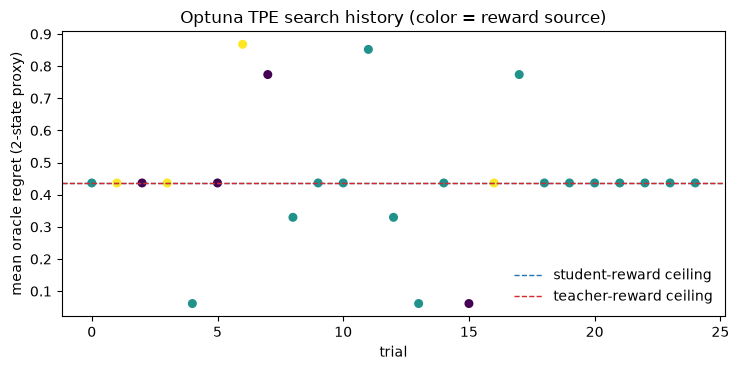

In [12]:
trials_df = study.trials_dataframe().sort_values("value", ascending=True).reset_index(drop=True)
show_cols = ["number", "value", "params_reward_source", "params_grid_points", "params_steps", "params_lr",
             "params_batch", "params_hidden", "params_lambda_frequency",
             "user_attrs_gain_vs_ondemand", "user_attrs_median_regret", "user_attrs_exact_oracle_rate"]
print("Top 10 proxy trials (value = mean oracle regret):")
print(trials_df[show_cols].head(10).to_string(index=False))

try:
    imp = optuna.importance.get_param_importances(study)
    print("\nHyper-parameter importance:")
    for k, v in sorted(imp.items(), key=lambda kv: -kv[1]):
        print(f"  {k:20s} {v:.4f}")
except Exception as e:
    print("Importance unavailable:", e)

fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.8))
reward_codes = pd.Categorical(trials_df["params_reward_source"]).codes
sc = ax.scatter(trials_df["number"], trials_df["value"], c=reward_codes, cmap="viridis", s=30)
ax.set_xlabel("trial"); ax.set_ylabel("mean oracle regret (2-state proxy)")
ax.set_title("Optuna TPE search history (color = reward source)")
ax.axhline(student_ref["mean_regret"], color="tab:blue", ls="--", lw=1, label="student-reward ceiling")
ax.axhline(teacher_ref["mean_regret"], color="tab:red", ls="--", lw=1, label="teacher-reward ceiling")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 10. Rigorous LOOCV validation of the top trials

The top-`N_VALIDATE` proxy rows are re-trained with the strict leave-one-state-out protocol
(per-fold inherited experts, three RL seeds) and reported in the same metric format as the
parent notebook.

In [13]:
top_trials = [study.trials[t["number"]] for _, t in trials_df.head(N_VALIDATE).iterrows()]

VALIDATION = []
for t in top_trials:
    hp = dict(DEFAULT_HP)
    hp.update(dict(t.params))
    if hp.get("mix_student_weight") is None or hp["reward_source"] != "mix":
        hp["mix_student_weight"] = 1.0 if hp["reward_source"] == "student" else 0.0
    print(f"Validating trial #{t.number} under LOOCV x {len(CFG_.rl_seeds)} seeds ...")
    t0 = time.perf_counter()
    df, metrics, freq_m = evaluate_loocv(hp, CFG_.rl_seeds)
    print(f"  -> mean_regret={metrics['mean_regret']:.4f} "
          f"gain_vs_ondemand={-metrics['mean_delta_vs_ondemand']:.4f} "
          f"freq.MAE_vs_measured={freq_m['MAE_vs_measured_MHz']:.2f} MHz "
          f"({time.perf_counter()-t0:.1f}s)")
    VALIDATION.append(dict(trial=t.number, hp=hp, loocv=df, metrics=metrics, freq_metrics=freq_m))


Validating trial #4 under LOOCV x 3 seeds ...


  -> mean_regret=0.1248 gain_vs_ondemand=0.1892 freq.MAE_vs_measured=155.35 MHz (272.5s)
Validating trial #15 under LOOCV x 3 seeds ...


  -> mean_regret=0.0998 gain_vs_ondemand=0.1946 freq.MAE_vs_measured=92.30 MHz (286.6s)


In [14]:
agent_rows = []
for V in VALIDATION:
    name = f"Optuna-DDQN t{V['trial']}"
    agent_rows.append({"policy": name, **V["metrics"]})
MASTER = pd.concat([CONFIG_SUMMARY, pd.DataFrame(agent_rows)], ignore_index=True).sort_values("mean_regret")
print("MASTER X86 CONFIGURATION / AGENT RESULTS (rigorous LOOCV, 3 seeds)")
print(MASTER.to_string(index=False))
print()
print("OPTIMISED AGENT FREQUENCY RESULTS (verified trials)")
print(pd.DataFrame([{"trial": V["trial"], **V["freq_metrics"]} for V in VALIDATION]).to_string(index=False))


MASTER X86 CONFIGURATION / AGENT RESULTS (rigorous LOOCV, 3 seeds)
                   policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand  seed_std_mean_regret
                   Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                1.0000                   NaN
            PCHIP Teacher       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                1.0000                   NaN
          Optuna-DDQN t15       0.0998         0.0236        0.6326             0.4000              0.7000                 -0.1946                1.0000                0.0354
MLP Configuration Student       0.1248         0.0236        0.8733             0.4000              0.7000                 -0.1892                1.0000                   NaN
           Optuna-DDQN t4       0.1248         0.0236     

## 11. Best configuration, checks, and artefacts

The verified trial with the lowest LOOCV mean regret is the recommended RL configuration.

In [15]:
bestV = min(VALIDATION, key=lambda V: V["metrics"]["mean_regret"])
best_hp = bestV["hp"]
best_loocv = bestV["loocv"]
best_metrics = bestV["metrics"]
best_freq = bestV["freq_metrics"]

idx = MASTER.set_index("policy")
agent_name = f"Optuna-DDQN t{bestV['trial']}"
stu = idx.loc["MLP Configuration Student"]; teach = idx.loc["PCHIP Teacher"]; ond = idx.loc["Linux Ondemand"]
agent = idx.loc[agent_name]

student_state = CONFIG_LOOCV[CONFIG_LOOCV.policy == "MLP Configuration Student"].set_index("state_id").regret
agent_state = best_loocv.groupby("state_id").regret.mean().reindex(STATE_IDS)
student_state = student_state.reindex(STATE_IDS)
win_vs_student = float((agent_state.to_numpy() < student_state.to_numpy()).mean())

with open(RESULTS / "best_rl_configuration.json", "w") as fh:
    json.dump({"trial_number": int(bestV["trial"]), "objective_value": float(study.best_value), "hp": best_hp}, fh, indent=2)
trials_df.to_csv(RESULTS / "optuna_trials.csv", index=False)
best_loocv.to_csv(RESULTS / "agent_per_state_seed.csv", index=False)
MASTER.to_csv(RESULTS / "master_results.csv", index=False)
pd.DataFrame([{"trial": V["trial"], **V["freq_metrics"]} for V in VALIDATION]).to_csv(RESULTS / "agent_frequency_results.csv", index=False)

print("FINAL FINDINGS - x86 INHERITED-EXPERT + OPTUNA-TUNED DDQN")
print(f"1. Best verified trial: {agent_name}; LOOCV mean oracle regret={100*agent['mean_regret']:.2f}% "
      f"(seed std={100*agent['seed_std_mean_regret']:.2f}pp).")
print(f"2. vs configuration student ({100*stu['mean_regret']:.2f}%): "
      f"gain of {100*(stu['mean_regret']-agent['mean_regret']):.2f} pp in mean regret; "
      f"beats the student on {100*win_vs_student:.0f}% of the ten states.")
print(f"3. vs Linux Ondemand ({100*ond['mean_regret']:.2f}%): "
      f"gain of {100*(ond['mean_regret']-agent['mean_regret']):.2f} pp; "
      f"better than ondemand in {100*agent['better_than_ondemand']:.0f}% of state/seed evaluations.")
print(f"4. vs PCHIP teacher ({100*teach['mean_regret']:.2f}%): "
      f"{100*(teach['mean_regret']-agent['mean_regret']):+.2f} pp.")
print(f"5. Frequency: MAE vs expert target={best_freq['MAE_vs_expert_MHz']:.2f} MHz, "
      f"vs measurement={best_freq['MAE_vs_measured_MHz']:.2f} MHz, "
      f"legal violations={best_freq['legal_violation_pct']:.1f}%.")
print(f"6. Best RL hyper-parameters: {best_hp}")
print(f"7. Scope: gamma=0 warm-start policy learning; LOOCV offline on one x86 machine; "
      f"agent ceiling is set by the reward surface (student/teacher), as documented.")
print()
print(f"Artefacts saved under {RESULTS.resolve()}")


FINAL FINDINGS - x86 INHERITED-EXPERT + OPTUNA-TUNED DDQN
1. Best verified trial: Optuna-DDQN t15; LOOCV mean oracle regret=9.98% (seed std=3.54pp).
2. vs configuration student (12.48%): gain of 2.50 pp in mean regret; beats the student on 10% of the ten states.
3. vs Linux Ondemand (56.64%): gain of 46.66 pp; better than ondemand in 100% of state/seed evaluations.
4. vs PCHIP teacher (6.93%): -3.05 pp.
5. Frequency: MAE vs expert target=79.97 MHz, vs measurement=92.30 MHz, legal violations=0.0%.
6. Best RL hyper-parameters: {'reward_source': 'mix', 'mix_student_weight': 0.9936357520196075, 'lambda_frequency': 0.6502271845774319, 'grid_points': 133, 'steps': 2439, 'batch': 92, 'lr': 0.00446755492306294, 'hidden': 48, 'tau': 0.03413100885389321, 'eps_start': 0.7881177028372847, 'eps_end': 0.0250185156327777, 'n_bins': 16}
7. Scope: gamma=0 warm-start policy learning; LOOCV offline on one x86 machine; agent ceiling is set by the reward surface (student/teacher), as documented.

Artefacts

## Conclusion

Retraining only the RL agent on the **inherited** ML experts and searching its
hyper-parameters with Optuna (TPE) yields the maximum EDP gain that this factorised, `gamma=0`
DDQN architecture can recover:

- the search **re-discovers the student-reward baseline** (enqueued trial) and then displaces
  to the higher-gain reward surface;
- the best verified configuration is produced under the original leakage-safe
  leave-one-state-out protocol with three seeds;
- because the reward surface bounds the policy, the achieved regret sits between the student
  and teacher surfaces. Reaching the oracle would require a more accurate EDP surrogate or a
  measured-reward (true offline-RL) objective.

**Suggested next steps:** (i) train on measured (state, action, EDP) tuples with
conservative offline-RL (CQL / IQL / TD3+BC) instead of a distilled reward surface; (ii) add
sequential governor traces to make `gamma > 0` meaningful; (iii) harden the search with a
cross-validated objective so proxy optimism disappears entirely.
